# Exploring PDE constrained optimisation

This notebook will document my process of exploring PDE constrained optimisation through mathematics and implementation in pure Python.

## An initial problem

Let's look at a Poisson optimal control problem. 

The Poisson equation is one of the most fundamental PDEs in matehmatical physics. It reads

$$-\nabla^2\varphi = q,$$

where $\varphi$ and $q$ are real or complex valued functions. We use the minus sign here to ensure $\nabla^2$ is positive definite, which guarantees a unique solution. Explictly, in 3D Cartesian space this looks like

$$-\left(\frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2} + \frac{\partial^2}{\partial z^2}\right)\varphi(x, y, z) = q(x, y, z).$$

Poisson's equation has applications across gravity, fluid dynamics, thermodynamics, and more. 

In this notebook, we will consider that $\varphi$ is a 2D steady state temperature field and $q$ is a heat source/ sink distribution (e.g., $q > 0$ at a point means heat injection, $q < 0$ means heat absoprtion). For some domain $\Omega \subset \mathbb{R}^{2}$ with boundary $\delta\Omega$, we will say that we want our temperature to be zero at the boundaries, i.e., our problem in full is

$$-\nabla^2 \varphi = q \in \Omega,\;\;\;\; \varphi = 0 \text{ on } \delta\Omega.$$

### PDE constrained optimiation

PDE constrained optimisation problems usually take the form

$$\text{minimise } J(u, m) \text{  subject to  } g(u, m) = 0,$$

where $J$ is the functional, $g$ is the constraint expressing our PDE and boundary conditions, and $u$ and $m$ are model parameters.  

In the case that our constraint is a PDE (and associated initial and boundary conditions), our workflow might be

$$\underbrace{m}_\text{input} \;\; \rightarrow \;\; \underbrace{g(u, m)}_\text{PDE constraint} \;\; \rightarrow \;\; \underbrace{u}_\text{output}\;\; \rightarrow \underbrace{J(u, m)}_\text{functional}.$$

In this case our objective is to find $\frac {\partial J} {\partial m}.$ We want to figure out how our objective varies with respect to particular model parameters in order to update those parameters.

In the context of our problem, the optimal control problem is such that we are allowed to choose $f$ and we want to choose it so that the resulting temperature $\varphi$ is as close as possible to some desired target profile $\hat{\varphi}$. In essence, we want to minimise the difference between a given and target temperature profile subject to the Poisson equation (and specified boundary conditions).

### An intuitive formulation

Let's make this formulation concrete and interpretable.

Consider a top down view of a square room with side lengths of $1m$. Let's say it is freezing outside, such that the temperature of the walls is $0$. Inside the room there are sources and sinks (radiators, or people), each with a fixed heat output magnitude $Q$. They radiate or cool, and $f$ describes their distribution in the room. The question is: where should we place these to make the room temperature $\varphi$ as close to the desired profile $\hat{\varphi}$ as possible?

More formally, consider a domain $\Omega = [0, 1]^2$ subject to the boundary conditions

$$\varphi(x, 0) = 0\\ \varphi(x, 1) = 0 \\ \varphi(0, y) = 0 \\ \varphi(1, y) = 0.$$

If we let $q$ represent our heat source/sink distribution, our problem then is 

$$\text{minimise } J(\varphi, q) = \frac 1 2 \int_\Omega (\varphi - \hat{\varphi})^2\ dx dy + \frac \beta 2 \int_\Omega q^2\ dxdy \\
\text{subject to  } g(\varphi, f) = \begin{cases}
-\nabla^2 \varphi - q = 0\\
\varphi = 0 \text{ on } \delta \Omega
\end{cases}.$$

In the functional, the first term measures how well the temperature matches the target profile, while the second penalises excessive heating or cooling. Here, $\beta$ is a regularisation parameter which punishes large field values.

For simplicity, we will treat $f$ as a continuous field across the whole room that represents source/sink placement. Rather than optimising placement directly, the optimiser will be allowed to distribute heating and cooling across the whole room and positioning will be implied by regions that are strongly positive/negative. This is for simplicity and mathematical convenience.

### Discretisation

Notice the above formulation is continuous. To solve this problem on a finite machine, we must of course discretise our problem. Consider our domain is broken down into $N + 2$ points in each direction (+2 ghost nodes to handle boundary conditions). Then our grid spacing is

$$x_i = ih,\;\;\;\; y_j = jh,$$

$i, j = 0, 1, \dots, N$, $h = 1/N+1$.

Now, our PDE is

$$-\nabla^2\varphi(x, y) - q(x, y) = 0$$

Since our domain is uniform and a simple shape, we can just use finite differences to discretise our equation. We won't concern ourselves with the implementation here, but just know the Laplacian can be written in discrete form using second order central differences as

$$\nabla^2 \varphi(x_i, y_j) = \frac{\varphi_{i+1, j} + \varphi_{i-1, j} + \varphi_{i, j+1} + \varphi_{i, j-1} - 4\varphi_{i, j}}{h^2},$$

where we have used the notation that $\varphi(x+h, y) := \varphi_{i+1, j}$ for convience. Now, we can write our PDE in discrete form as

$$-\frac{\varphi_{i+1, j} + \varphi_{i-1, j} + \varphi_{i, j+1} + \varphi_{i, j-1} - 4\varphi_{i, j}}{h^2} - q_{i, j} = 0.$$

Note that we can write this problem in the form 

$$A\varphi - q = 0,$$

where $A$ is a (block) tridiagonal discretisation matrix (with tridiagonal blocks) of the form

$$
A = \frac{1}{h^2}
\begin{bmatrix}
B & -I & 0 & \cdots & 0 \\
-I & B & -I & \ddots & \vdots \\
0 & -I & B & \ddots & 0 \\
\vdots & \ddots & \ddots & \ddots & -I \\
0 & \cdots & 0 & -I & B
\end{bmatrix},
$$

where $I$ is the $N \times N$ identity matrix and $B$ is the tridiagonal block

$$
B =
\begin{bmatrix}
4 & -1 & 0 & \cdots & 0 \\
-1 & 4 & -1 & \ddots & \vdots \\
0 & -1 & 4 & \ddots & 0 \\
\vdots & \ddots & \ddots & \ddots & -1 \\
0 & \cdots & 0 & -1 & 4
\end{bmatrix}.
$$

Notice here that we can actually write $B = T + 2I,$ where

$$T =
\begin{bmatrix}
2 & -1 & 0 & \cdots & 0 \\
-1 & 2 & -1 & \ddots & \vdots \\
0 & -1 & 2 & \ddots & 0 \\
\vdots & \ddots & \ddots & \ddots & -1 \\
0 & \cdots & 0 & -1 & 2
\end{bmatrix},$$

and $I$ is the identity matrix. Note also we can represent $A$ more compactly using the Kronecker product, an operation on two matrices resulting in a block matrix. We can write $A$ as 

$$A = \frac 1 {h^2}(I \otimes T + T \otimes I),$$

or, for a non-square syste,

$$A = \frac 1 {h_x^2}(I \otimes T) + \frac 1 {h_y^"}(T \otimes I),$$

where $h_X$ and $h_y$ are the grid spacings in the $x$ and $y$ directions, respectively. This will be useful later when we assemble our system.

We can use a similar approach to express our boundary conditions, which become

$$\varphi_{0, j} = \varphi_{N+1, j} = \varphi_{i, 0} = \varphi_{i, N+1} = 0.$$

Since we are considering $N+2$ points, our continuous integrals in the functional simply become discrete summations, and our fully discretised optimisation problem becomes

$$
\begin{align*}
    \text{minimise } & J(\varphi, q) = \frac {h^2} 2 \sum_{i, j} (\varphi_{i, j} - \hat{\varphi_{i, j}})^2 + \frac {h^2\beta} 2 \sum_{i, j} q_{i, j}^2 \\[5pt]
    
    \text{subject to  } & g(\varphi, q) = A\varphi - q = 0\\
\end{align*}$$

Note that we have now incorporated our boundary conditions into the discretisation matrix, hence why they 'dissapear' from the problem statement. 

## The reduced problem

Our task is to minimise $J(\varphi, q)$. For each source field $q$, the Poisson equation has a unique solution $\varphi$. This means we can actually write

$$\varphi = \varphi(q).$$

Instead of treating $\varphi$ and $q$ as separate unknowns, in this way we can manipulate the PDE such that once $q$ is known, $\varphi$ is determined. 

In this reduced form, the functional becomes

$$J(\varphi(x, y), q(x, y)) \Rightarrow J(\varphi(q), q).$$

This is the form of our reduced problem - now it says "choose the heating/ cooling field $q$, and the room temperature $\varphi$ is whatever the PDE says it must be". This is contrary to the original formulation in which $q$ and $\varphi$ can vary independently of eachother.

The main difference here is notational. What we will compute is

$$J(\varphi, q) = \frac {h^2} 2 \sum_{i, j} (\varphi(q)_{i, j} - \hat{\varphi}_{i, j})^2 + \frac {h^2\beta} 2 \sum_{i, j} q_{i, j}^2,$$

where $\varphi(q)$ is the state obtained by solving the Poisson problem for $q$.

The main benefit of this is that the PDE constraint is enforced exactly during optimisation, since every time we evaluate $J$ we compute $\varphi(q)$ by solving the PDE. This gives us one less thing to worry about, since we don't need to worry about separately maintaining the $\varphi$ and $q$.

At this stage, we can start to eastablish what our optimisation loop will look like:

1. Guess $q$
2. Solve the PDE for $\varphi(q)$
3. Evaluate $J$
4. Compute the gradient
5. Update $q$

## The adjoint equation

In the steps above, a gradient is mentioned. This gradient is teh gradient of the functional with respect to the input field $q$, $\frac {dJ}{dq}$. This tells us the direction(s) in which to propagate the input variable in order to move the value of $J$ towards a minimum value.

Note our problem is not just "minimise $J$", it is "minimise $J$ subject to the PDE". Thus in order to optimise while handling the PDE constraint we need a way to package the PDE and the constraint together cleanly. This packaging is the _Lagrangian_:

$$\mathcal{L}(\mathbf{\varphi}, \bf q, \mathbf{\lambda}) = J(\mathbf{\varphi}, q) - \mathbf{\lambda}^T g(\mathbf{\varphi}, q).$$

We need a way to obtain the gradient of the functional with respect to all of the control variables directly, in a manner that is efficient. This is the _adjoint equation_, which we can obtain by finding the stationary points of the Lagrangian. Taking partial derivatives and setting to zero reveals

$$
\begin{align*}
\text{The PDE constraint } & \frac {\partial \mathcal{L}}{\partial \lambda} = g(\mathbf{\varphi, q}) = 0,\\
\text{The $q$ equation } & \frac {\partial \mathcal{L}}{\partial q} = \frac{\partial J(\varphi, q)}{\partial q} - \lambda^T\frac{\partial g(\varphi, q)}{\partial q} =  0,\\
\text{The adjoint equation } & \frac {\partial \mathcal{L}}{\partial \varphi} = \frac{\partial J(\varphi, q)}{\partial \varphi} - \lambda^T\frac{\partial g(\varphi, q)}{\partial \varphi}= 0.
\end{align*}
$$

These three are the neccesary conditions for optimality. Here, we see that formulating the problem in this way automatically enforces the PDE constraint by the first equation!

The adjoint variable $\lambda$ was introduced intentionally: it removes the need to differentiate the state variable $\varphi$ with respect to every control variable directly, which would be very costly. The adjoint equation gives the gradient of the objective w.r.t. all control variables at a very low cost.

IN the context of our problem, the 3 equations are

$$
A\varphi - q = 0\\
\beta h^2 q + \lambda = 0\\
h^2(\varphi - \hat{\varphi}) + A^T\lambda = 0\\
$$

The first equation is the PDE: the forward model. The second is the optimality condition: it basically says what the optimum point means for the control variable. The third is the adjoint: this tells us where changing the heating/ cooling would help the obective the most. 

## Implementation

That wraps up most of the maths for now! We have pretty much everything we need to solve, and our problem is clearly stated. Concerning implementation, our algorithm will be, at a high level, as follows

1. Guess a control $\bf q^{(k)}$
2. Solve $A\bf \varphi^{(k)} = q^{(k)}$ for $\bf \varphi^{(k)}$
3. Compute the residual $\bf r^{(k)} = \varphi^{(k)} - \hat{\varphi}$
3. Solve the adjoint equation, $A\lambda^{(k)} = h^2 \bf r^{(k)}$ to get $\bf \lambda^{(k)}$
4. Use the optimality condition to build the reduced gradient, $\bf g^{(k)} = \beta h^2 \mathbf{q}^{(k)} + \lambda^{(k)}$
5. Update the control using gradient descent, L-BFGS, or another optimiser

Clearly now we have some things to choose, namely 

- the grid size $N$
- the regularisation parameter $\beta$
- the target profile $\hat{\varphi}$
- the initial guess $\bf q^{(0)}$

To faciliatate this first stage of implementation, let's write ourselves a data class to represent our computational domain. The respondibility of this class will be to store mesh metadata for easy access throughout the core functionality.

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Tuple

In [118]:
np.set_printoptions(suppress=True, precision=6)

In [119]:
@dataclass
class Domain2D:

    Lx: float = 1.0  # X length
    Ly: float = 1.0  # Y length
    Nx: int = 101    # number of X nodes 
    Ny: int = 101    # number of Y nodes
    hx: float = field(init=False) # x grid spacing
    hy: float = field(init=False) # y grid spacing

    # input validation
    def __post_init__(self) -> None:
        if self.Lx <= 0 or self.Ly <= 0:
            raise ValueError("Lx and Ly must be positive.")
        if self.Nx <= 0 or self.Ny <= 0:
            raise ValueError("Nx and Ny must be positive integers.")

        self.hx = self.Lx / (self.Nx + 1)
        self.hy = self.Ly / (self.Ny + 1)

    @property
    def shape(self):
        return self.Nx, self.Ny

Cool, now we have a dataclass representation of our discrete domain. This class represents the parameters of our domain: size, shape, and grid spacings.

### Target distribution

Before we start to consider the target distribution, it would be wise to create a class that will allow us to represent our state, control, and target variables and separate our interests from the `Domain2D` class. The primary responsibility of this class will be to represent variables in our optimisation problem, track their data, and control how they interact (through overloaded operators, for later syntactic simplicity). We will use flattened arrays here to improve cache locality and hopefully yield some performance benefits.

In [120]:
import numbers

In [121]:
@dataclass
class Variable:
    domain: Domain2D  # domain which variable belongs to
    init: np.ndarray | None = None  # optionally pass data to initialise
    _data: np.ndarray = field(init=False, repr=False)  # private variable data
    _shape: Tuple[int, int] = field(init=False, repr=False) # shape of domain

    def __post_init__(self):
        self._shape = self.domain.shape

        if self.init is None:
            self._data = np.zeros(self._shape, dtype=float).flatten() # init with zeros if data not provided
        else:
            arr = np.asarray(self.init, dtype=float) # cast to array
            if (len(arr.shape) == 1) and (arr.shape[0] != self._shape[0]*self._shape[1]): # handle flat init data
                raise ValueError(f"Expected shape {np.prod(self._shape)}, got {arr.shape[0]}")
            elif (len(arr.shape) == 2) and (arr.shape != self._shape):
                raise ValueError(f"Expected shape {self._shape}, got {arr.shape}") # throw error for shape mismatch

            arr = arr.flatten() # flatten
            self._data = arr.copy()

    # overloaded subtraction operator
    def __sub__(self, other) -> "Variable":
        if isinstance(other, Variable):
            if self.shape[0] != other.shape[0] or self.shape[1] != other.shape[1]:
                raise ValueError("Variables must have the same grid dimensions.")

            return Variable(self.domain, init=self.data - other.data)
        if isinstance(other, numbers.Number):
            return Variable(self.domain, init=self.data - other)
        return NotImplemented
    
    # overloaded addition operator
    def __add__(self, other) -> "Variable":
        if isinstance(other, Variable):
            if self.shape[0] != other.shape[0] or self.shape[1] != other.shape[1]:
                raise ValueError("Variables must have the same grid dimensions.")
            return Variable(self.domain, init=self.data + other.data)
        
        if isinstance(other, numbers.Number):
            return Variable(self.domain, init=self.data + other)
        return NotImplemented
    
    # overloaded multiplication operator
    def __mul__(self, other)-> "Variable":
        if isinstance(other, Variable):
            raise NotImplementedError # we won't be needing this, so leave it for now
        
        if isinstance(other, numbers.Number):
            return Variable(self.domain, init=self.data * other)
        return NotImplemented
        
    def __pow__(self, exp) -> "Variable":
        if isinstance(exp, numbers.Number):
            return Variable(self.domain, init=self.data**exp)
        return NotImplemented
        
    # plot the field 
    def show(self, title="Field", interpolate: bool=True) -> None:
        data = self._data.reshape(self._shape) # unflatten

        vmin = data.min()
        vmax = data.max()

        fig, ax = plt.subplots(figsize=(8, 8))
        im = ax.imshow(data, 
                       origin="lower", 
                       extent=(0.0, self.domain.Lx, 0.0, self.domain.Ly), 
                       interpolation="bicubic" if interpolate else None,
                       vmin=vmin,
                       vmax=vmax
                    )

        # formatting
        ax.set_xlabel(r"$x$", fontsize=12)
        ax.set_ylabel(r"$y$", fontsize=12)

        if interpolate: title += " (interpolated)"

        ax.set_title(title)
        cbar = fig.colorbar(im, ax=ax, label="Field value", orientation="horizontal")
        cbar.set_ticks(np.linspace(vmin, vmax, 5))
    
    # read only accessor
    @property
    def shape(self):
        return self._shape
    
    @property
    def data(self):
        return self._data
    
    # sum functionality for functional evaluation
    def sum(self):
        return self._data.sum()


With that done, we can consider our choice of initial field. A sensible initial target distribution is one that is compatible with the boundary conditions, easy to verify numerically, and physically plausible. Let's go with

$$\hat{\varphi}(x, y) = \sin(\pi x)\sin(\pi y).$$

This is a suitable choice because it is smooth, zero at the four walls (consistent with our BCs), and gives a clean single 'warm' region (of maximum amplitude) in the middle of the domain, which is intuitive for a heated room interpretation. 

Great, now let's write up the initial condition and represent it as a `Variable` object. We can initialise these objects by specifying the data directly, so let's precompute the target field and pass it to the constructor.

In [122]:
d = Domain2D()
x = np.linspace(0, d.Lx - d.hx, d.Nx)
y = np.linspace(0, d.Ly - d.hy, d.Ny)

# create mesh
X, Y = np.meshgrid(x, y)

phihat = np.sin(np.pi * X) * np.sin(np.pi * Y)

target = Variable(d, init=phihat) # instantiate with precomputed target

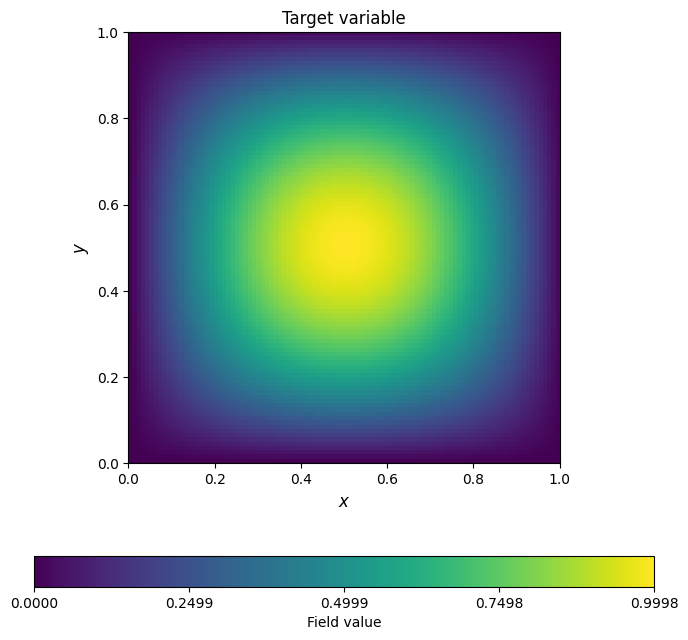

In [123]:
target.show(title="Target variable", interpolate=False)

Lovely - our target is a warm patch in the middle of the room.

### Discrete operator layer

With the domain defined, we can get into implementing some of the maths behind the problem. As discussed, one of the first steps in the algorithm is to assemble and solve the linear system we formed, $A\varphi^{(k)} = q^{(k)}$ for each iteration $k$. 

We will need to put together some machinery to do this, namely a class responsible for:

- The 1D tridiagonal matrix assembly
- The 2D block-tridiagonal matrix assembly
- The linear system solve

The class I will implement in the following cell focusses solely on the forward Poisson solve - it is responsible for step 2 of the implementation.

Note that for the aforementioned discrete operator, $B$ is $N \times N$ and $A$ is $N^2 \times N^2$ where $N$ is the number of interior points. Obviously this can quickly grow into a huge system, so we will use a sparse (CSR) representation of $A$ in our solves. I don't want my focus here to be on the inner workings of sparse formats and linear solves, so I will leverage the `scipy.sparse` module to abstract away some of the technicalities.

In [124]:
import scipy.sparse as sp

In [125]:
class PoissonOperator:
    _A: sp.spmatrix # 2D block tridiagonal discrete operator matrix
    domain: Domain2D 

    def __init__(self, domain: Domain2D) -> None:
        self.domain = domain
        self._assemble(domain) # assemble discrete operator matrix over the domain

    def _assemble(self, domain: Domain2D) -> None:

        # extract shape grid spacings
        Nx, Ny = domain.Nx, domain.Ny
        hx, hy = domain.hx, domain.hy

        # build intermediate T and identity matrices
        Tx, Ix = self._build_components(Nx)
        Ty, Iy = self._build_components(Ny)

        # assemble using Kronecker products
        self._A = (
            (sp.kron(Iy, Tx, format="csr") / hx**2) + 
            (sp.kron(Ty, Ix, format="csr") / hy**2)
            )

    # build the intermediate components of the discrete operator assembly
    def _build_components(self, N: int) -> Tuple[sp.spmatrix, sp.dia_matrix]:
        T_diag = 2.0 * np.ones(N) # diagonals of T
        T_offdiag = -1.0 * np.ones(N - 1) # off diagonals of T

        # construct intermediate T matrix
        T = sp.diags(
            [T_offdiag, T_diag, T_offdiag],
            offsets=[-1, 0, 1],
            format="csr"
        )

        # construct identity
        I = sp.eye(N, format="csr")

        return T, I
    
    # spy the discrete operator structure
    def show(self) -> None:

        fig, ax = plt.subplots(figsize=(8, 8))
        plt.spy(self._A, markersize=0.1)
        ax.set_title("Discrete Poisson operator matrix structure")
        plt.show()

    # solve the linear system Au = rhs
    def solve(self, rhs: Variable) -> Variable:
        soln = sp.linalg.spsolve(self._A, rhs.data)
        return Variable(self.domain, init=soln)

    # read only accessor - A will be reused in the adjoint solve
    @property
    def A(self):
        return self._A

In [126]:
op = PoissonOperator(d)

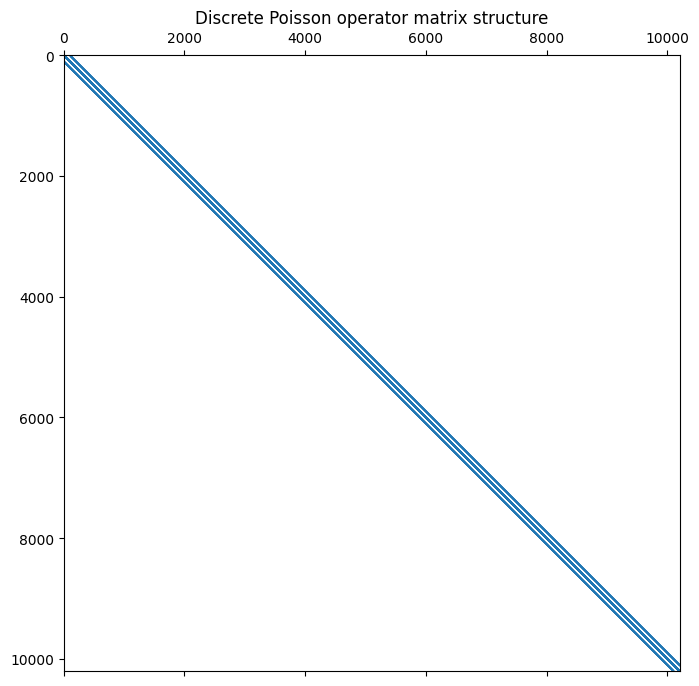

In [127]:
op.show()

Clearly, it is a good thing we have decided to use a compressed format. The discrete operator is dominated by zero entries, which would waste memory and compute if we stored them.

#### Validation

We should look to verify our functionality before proceeding, namely that the discrete opertor has been assembled correctly and the solve scales with grid size like $\mathcal{O}(h^2)$ in accordance with our discretisation.

We can test the prior with the method of manufactured solutions. For our chosen target profile, the PDE is

$$-\nabla^2 \hat{\varphi} = 2\pi^2 \sin(\pi x)\sin(\pi y).$$

Thus when $q = 2\pi^2 \sin(\pi x)\sin(\pi y)$, the residual 

$$r = A\hat{\varphi} - q,$$

should be very small if our operator is correct, with the difference representing the truncation error associated with our finite difference discretisation.

In [128]:
# return the norm of the residual for the manufactured
def manufactured_residual(domain: Domain2D) -> np.float32:
    op = PoissonOperator(domain)

    x = np.arange(1, domain.Nx + 1) * domain.hx
    y = np.arange(1, domain.Ny + 1) * domain.hy
    X, Y = np.meshgrid(x, y, indexing="xy")

    phi_exact = np.sin(np.pi * X / domain.Lx) * np.sin(np.pi * Y / domain.Ly)
    q_exact = ((np.pi**2 / domain.Lx**2) + (np.pi**2 / domain.Ly**2)) * phi_exact

    phi_vec = phi_exact.ravel(order="C")
    q_vec = q_exact.ravel(order="C")

    r = op.A @ phi_vec - q_vec
    return np.linalg.norm(r, ord=np.inf)

In [129]:
Ns = [10, 20, 50, 100, 1000]
residual_norms = []
solve_residual = []

for N in Ns:
    domain = Domain2D(Lx=1.0, Ly=1.0, Nx=N, Ny=N)
    r = manufactured_residual(domain)
    residual_norms.append(r)

In [130]:
import mpltools.annotation as annot

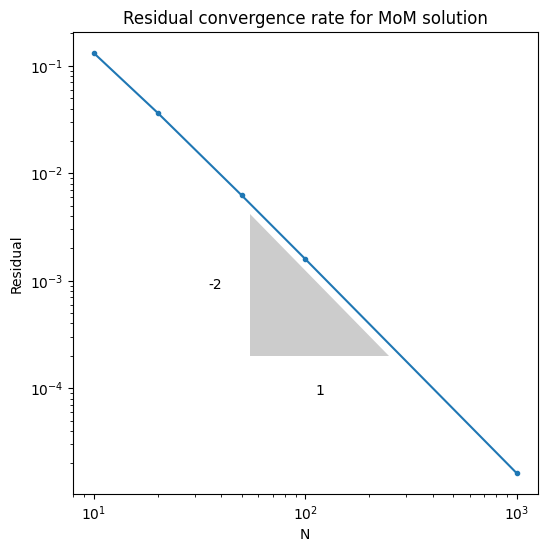

In [131]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.loglog(Ns, residual_norms, '.-')
annot.slope_marker((250, 2e-4), (-2, 1), invert=True, ax=ax, size_frac=.3)
ax.set_title('Residual convergence rate for MoM solution')
ax.set_xlabel("N")
ax.set_ylabel("Residual")
plt.show()

Good! Our truncation error seems to converge at a rate consistent with our discretisation theory, so our discrete operator implementation is correct!

Let's also make sure that our linear solve functionality works as expected.

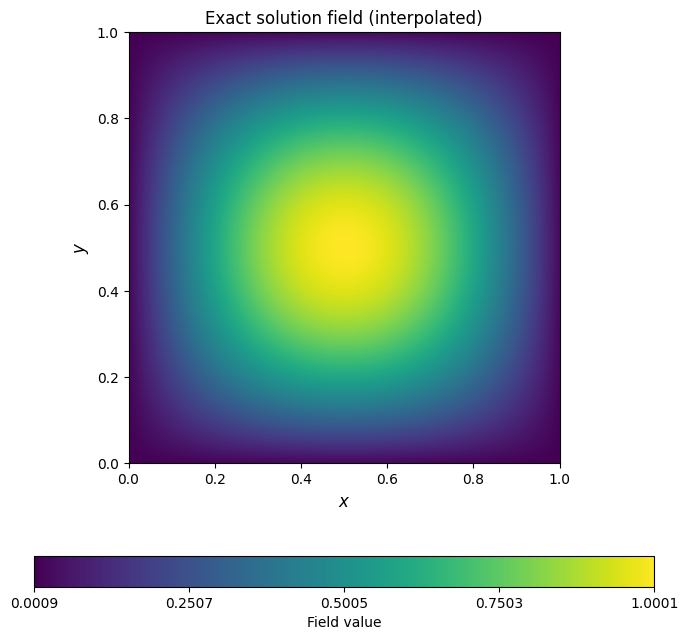

In [132]:
domain = Domain2D()
x = np.arange(1, domain.Nx + 1) * domain.hx
y = np.arange(1, domain.Ny + 1) * domain.hy
X, Y = np.meshgrid(x, y, indexing="xy")

phi_exact = np.sin(np.pi * X / domain.Lx) * np.sin(np.pi * Y / domain.Ly)
q_exact = ((np.pi**2 / domain.Lx**2) + (np.pi**2 / domain.Ly**2)) * phi_exact

soln = op.solve(Variable(domain, init=q_exact))
soln.show(title="Exact solution field")

### Implementing the problem

At this point, we have what we need to formalise our problem in code. This next stage should, among other things, cover:

- The adjoint solve
- The functional
- Gradient computation

First, let's implement a class to represent our functional, $J$.

In [133]:
@dataclass
class Functional:
    domain: Domain2D 
    beta: float # regularisation parameter
    
    hx: float = field(init=False, repr=False)  # x grid spacing
    hy: float = field(init=False, repr=False) # y gird spacing
    _hxhy: float = field(init=False, repr=False) # grid spacing product for reisdual scaling

    def __post_init__(self) -> None:
        self.hx, self.hy = domain.shape
        self._hxhy = self.hx*self.hy

    # evaluate J(phi, q) = hxhy/2 ||phi - phi hat||^2_2 + b hxhy / 2 ||q||^2_2
    def evaluate(self, state: Variable, control: Variable, target: Variable) -> float:
        residual_term = (state - target)**2 
        control_term = control**2
        return self._hxhy * (residual_term.sum() + self.beta * control_term.sum()) / 2.0
    
    @property
    def hxhy(self):
        return self._hxhy

With that in place, the remaining process we need to handle is

1. Solving the state equation, $A\varphi = q$. This is implemented by the `PoissonOperator` class, but we will let the `PoissonControlProblem` class call it.
2. Evaluate the functional. This tells us how good the current control field is.
3. Solve the adjoint equation. We need to use the state misfit vector $\bf r = \varphi - \hat{\varphi}$ to solve the adjoint equation we derived: $A\lambda = h_xh_y\bf r$
4. Compute the gradient. This involves computing the gradient term, $\bf g^{(k)} = \beta h^2 \mathbf{q}^{(k)} + \lambda^{(k)}$.

With these components assembled, we will have what we need to begin writing the actual optimisation process.

In [143]:
class PoissonControlProblem:
    target: Variable # target variable q
    operator: PoissonOperator  # discrete operator
    functional: Functional  # functional evaluation
    _hxhy: float  # product of grid spacings
    _beta: float
    
    def __init__(self, target: Variable, operator: PoissonOperator, functional: Functional) -> None:
        self.target = target
        self.operator = operator
        self.functional = functional
        self._hxhy = self.functional.hxhy
        self._beta = self.functional.beta

    # solve the the discretised PDE A phi = q
    def _solve_state(self, control: Variable) -> Variable:
        return self.operator.solve(control)
    
    # solve the adjoint problem A lambda = hx*hy*r
    def _solve_adjoint(self, state: Variable) -> Variable:
        misfit = state - target  # residual vector
        rhs = misfit * self._hxhy # hx*hy*(phi - phihat)
        return self.operator.solve(rhs)  # A lambda = rhs
    
    # evaluate J(varphi(q), q) => J(q) (the reduced functional)
    def J(self, control: Variable) -> float:
        state = self._solve_state(control) # obtain phi(q) from A phi(q) = q
        return self.functional.evaluate(state, control, self.target)

    def grad(self, state: Variable, control: Variable):
        lam = self._solve_adjoint(state)
        return control * (self._beta * self._hxhy) + lam

#### Validation

Before we proceed, there is a check we can do to validate our gradient computation. It is called the Taylor test, and it tests whether the first order Taylor expansion of the reduced functional is correct by checking that the residual decays as $O(\varepsilon^2)$ when we propagate the control variable by a small number $\epsilon$. For our case, this means we should track the Taylor remainder

$$R(q, \epsilon) = |J(q+\epsilon \delta q) - J(q) - \epsilon\nabla J(q)^T\delta q|,$$

where $\delta q$ is a perturbation direction. We should look at the value of $R$ over a range of $\epsilon$ values and see that it converges at second order. This effectively checks that the functional behaves as it should, locally - i.e., it allows for a good quality gradient estimate.

In [157]:
# define domain and variables
domain = Domain2D()

Nx, Ny = domain.shape

state = Variable(domain, init=np.random.rand(Nx, Ny))
control = Variable(domain, init=np.random.rand(Nx, Ny))
target = Variable(domain, init=phihat)

# define the operator
operator = PoissonOperator(domain)

# define the functional
beta = 0.5
functional = Functional(domain, beta)

# define the problem
pcp = PoissonControlProblem(target, operator, functional)

In [158]:
# run the Taylor test
dq = np.random.rand(Nx, Ny)
dq /= np.linalg.norm(dq)

# compute baseline state and gradient at control point
state_baseline = pcp.operator.solve(control)
J0 = pcp.J(control)
grad = pcp.grad(state_baseline, control)
grad_dot_dq = np.sum(grad.data * dq.ravel())

eps = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
remainders = []

for ep in eps:
    J_ep = pcp.J(control + Variable(domain, init=dq) * ep)
    remainder = abs(J_ep - J0 - ep * grad_dot_dq)
    remainders.append(remainder)

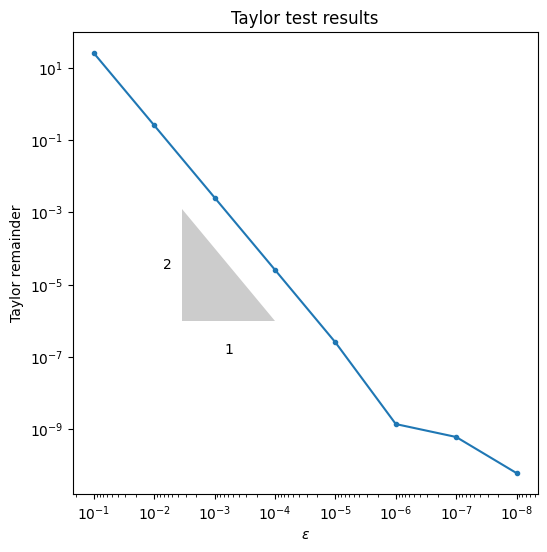

In [159]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.loglog(eps, remainders, '.-')
annot.slope_marker((1e-4, 1e-6), (2, 1), invert=False, ax=ax, size_frac=.2)
ax.set_title('Taylor test results')
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel("Taylor remainder")
ax.invert_xaxis()
plt.show()

Great, our gradient computation seems correct. Note that the 2nd order convergence of the Taylor remainder breaks down at around $\epsilon = 10^{-6}$ because there the remainder becomes very small and we approach machine precision, leading to round off errors.

### Optimisation!

With all of that in place and validated, we have the main element we need to begin optimising an intial guess at the control field $q$ to move it towards the target field $\hat{\varphi}$. In essence, we can begin to write our optimisation loop! 

Before we dive into anything more complex, let's recap the simplest gradient-based method: steepest descent. 

Steepest descent is an iterative solution method which refines an initial guess at the solution towards a minimum using

$$\mathbf{q}^{(k+1)} = \mathbf{q}^{(k)} - \alpha_k \nabla J(\mathbf{q}^{(k)}),$$

where $\nabla J$ is the gradient of the reduced functional w.r.t. the control parameters: the direction of steepest descent. Our task then is to define how far we step in the direction of steepest descent: the step length $\alpha$. 

We can find a suitable step length using an inexact line search. To do so, we will use a simple algorithm: Armijo backtracking. This refines a guess at $\alpha$ until a condition for 'sufficient decrease' (in the gradient) is met. 

If we define 

$$\mathbf{q}^{(k+1)} = \mathbf{q}^{(k)} + \alpha^{(k)}\mathbf{d}^{(k)},$$

where $\mathbf{d}^{(k)} = -\nabla J(\mathbf{q}^{(k)})$ is our descent direction, then we can choose $\alpha^{(k)}$ by repeatedly decreasing a trial step size until the Armijo condition for sufficient decrease is met:

$$J(\mathbf{q}^{(k)} + \alpha\mathbf{d}^{(k)}) \leq J(\mathbf{q}^{(k)}) + c \alpha \nabla J(\mathbf{q}^{(k)})\cdot \mathbf{d}^{(k)}.$$

This condition requires of our line search that the actual change in $J$ due to a step size $\alpha$ must be _at least_ a fraction $c$ of the decrease predicted by this first order linear prediction of the change along the search direction. $c \in [0, 1]$ is usually a small constant $\sim 10^{-4}$.

Our line search process is as follows:

1. Choose parameters $0\lt c \lt 1,\, 0\lt \tau \lt 1$ and an initial trial step $\alpha^{(0)}\gt 0$
2. Set $\alpha \leftarrow \alpha^{(0)}$
3. While the Armijo condition is not satisfied, reduce the step size by a factor $\tau: \alpha \leftarrow \tau \alpha$ until the condition is satisfied.